# SPA Module Creation

In [1]:
import clr
import sys
import System
import csv
import copy
import os

assembly_path = r".\DLL"
sys.path.append(assembly_path)
ref = clr.AddReference(r"SantecSPA")

import SantecSPA
import matplotlib.pyplot as plt
import numpy as np
import time

print(os.getpid())

spa = SantecSPA.SPAModule()

20836


# Use with Connected Instruments

## List Connected SPA and TSL Devices

In [2]:
# currently, the SDK can not scan for SPA-200 devices
# SPA-200 ID is the last 6 digits of the MAC address
# example: MAC = 00:26:32:f0:b4:ef, SPA-200 ID = f0b4ef
spaDev = "f0b4ef"

# this gets the list of TSL devices connected via USB
status, tslList = spa.GetTslDeviceList([])

print("TSL Devices:")
for item in tslList:
    print(item)
    

TSL Devices:
0


## Initialize

In [6]:
# Select the SPA and TSL device using information from above
tslDev = int(tslList[0])     # use first TSL

# Explicitly wrap tslDev as System.Int32: pythonnet resolves a plain
# Python int ambiguously between Initialize(string, uint tslGpibAddress)
# and Initialize(string, int tslUsbDeviceId), and was picking the GPIB
# overload instead of the USB one.
#status = spa.Initialize(spaDev, System.Int32(tslDev))

status = spa.Initialize(spaDev, "USB", 0, tslDev, "", 0)

print(status)

0


## Load Settings From File

In [7]:
# load settings from INI file
# change this to Setting_C-Band.ini or Setting_CL-Band.ini depending on SPA wavelength band
status = spa.LoadOperationSettingsFromFile(r".\settings\Settings_200_CL-Band.ini")

if (status < 0):
    print("Failed to load settings")
else:
    # print some important settings from the loaded INI file
    print("StartWave =", spa.Settings.StartWave)
    print("StopWave =", spa.Settings.StopWave)
    print("MeasurementMode =", spa.Settings.MeasurementMode)
    print("DistanceRange =", spa.Settings.DistanceRange)
    print("GaussianFilter =", spa.Settings.GaussianFilter)
    print("GaussianRadius =", spa.Settings.GaussianRadius)
    print("EnableRefractiveIndex =", spa.Settings.EnableRefractiveIndex)
    print("RefractiveIndex =", spa.Settings.RefractiveIndex)
    print("Power =", spa.Settings.Power)
    print("SpaNum =", spa.Settings.SpaNum)

# note that if a DSPA file is loaded beforehand, the settings will be replaced with the new settings

StartWave = 1500.0
StopWave = 1600.0
MeasurementMode = 0
DistanceRange = 30.0
GaussianFilter = False
GaussianRadius = 0.01
EnableRefractiveIndex = True
RefractiveIndex = 1.0
Power = -3.0
SpaNum = 200.0


## Change Settings

In [8]:
from System import Boolean

spa.SetOperationSettingsValue("GaussianFilter", Boolean(True))
spa.SetOperationSettingsValue("GaussianRadius", 0.01)
spa.SetOperationSettingsValue("EnableRefractiveIndex", Boolean(True))
spa.SetOperationSettingsValue("RefractiveIndex", 1.46)

print("GaussianFilter =", spa.Settings.GaussianFilter)
print("GaussianRadius =", spa.Settings.GaussianRadius)
print("EnableRefractiveIndex =", spa.Settings.EnableRefractiveIndex)
print("RefractiveIndex =", spa.Settings.RefractiveIndex)

GaussianFilter = True
GaussianRadius = 0.01
EnableRefractiveIndex = True
RefractiveIndex = 1.46


## Reference Scan

Measurement took 13.93 seconds


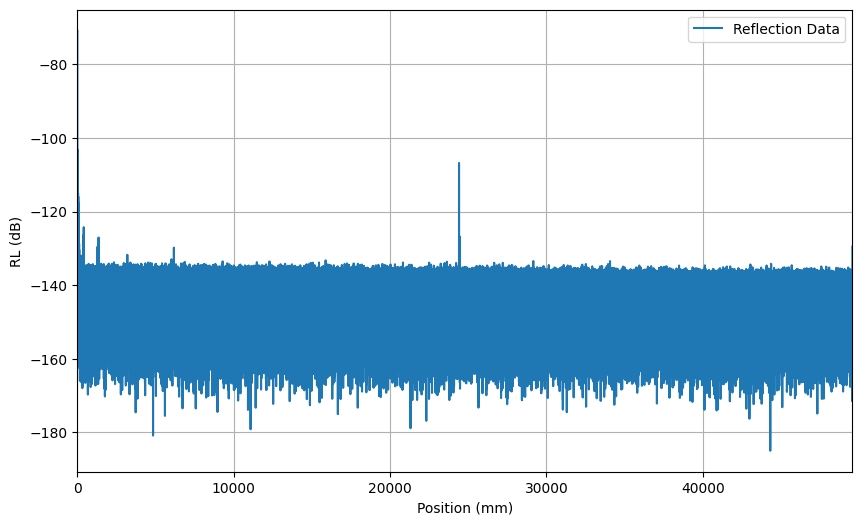

In [ ]:
# Note: disconnect the fiber for reference
# perform a reference scan using the current settings

startTime = time.perf_counter()

spa.SetOperationSettingsValue("MeasurementMode", 0)
spa.SetOperationSettingsValue("DistanceRange", 30)

# perform a reference scan
# subsequent measurements will use this reference
# this reference can be saved then used later without having to perform a reference scan
# using SetReflectanceReferenceOffset(reflectionReference)
status, reflectionReference = spa.ExecuteReflectionReference()

# optionally get the reference reflectance data
# use spa.GetReflectanceData(startPosition, endPosition, distanceCorrectionPosition, [], [], true)
# to specify the range of data to return and Distance Correction Position 
# (more details below)
# if the first 3 parameters are not specified as it is below, the entire range of data is returned
status, xValues, yValues = spa.GetReflectanceData([], [], True) # True -> Reference

endTime = time.perf_counter()

print(f"Measurement took {endTime - startTime:.2f} seconds")

fig = plt.figure(figsize=(10, 6))
plt.plot(xValues, yValues, label='Reflection Data')
plt.xlabel('Position (mm)')
plt.ylabel('RL (dB)')
plt.legend()
plt.grid(True)
plt.xlim(min(xValues), max(xValues))
plt.show()

# clean up to free up memory
del xValues, yValues
plt.close(fig)

## Measurement Scan Using ExecuteReflectionMeasurement

Measurement took 9.26 seconds


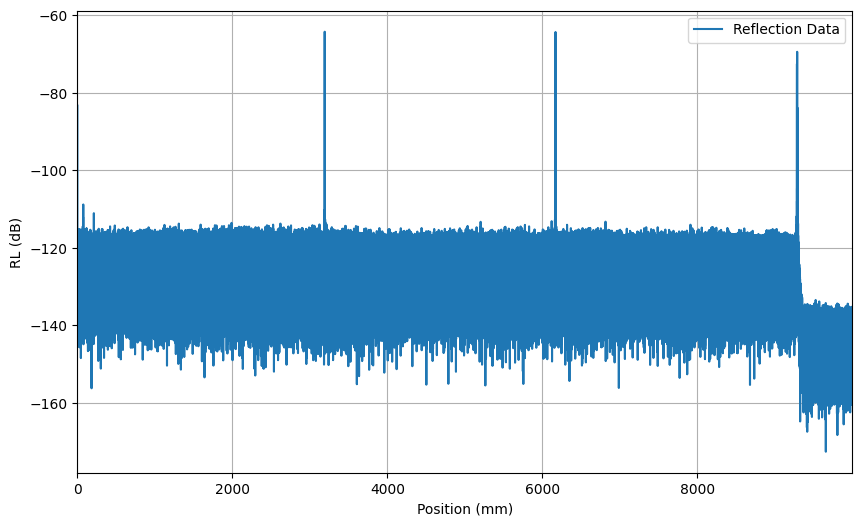

In [ ]:
# Note: reconnect the DUT for measurement
# perform a measurement scan using the current settings
# using ExecuteReflectionMeasurement will do a one-shot scan and processing

startTime = time.perf_counter()

spa.SetOperationSettingsValue("MeasurementMode", 0)
spa.SetOperationSettingsValue("DistanceRange", 30)

# specify the range for the returned data
startPosition = 0
endPosition = 10000

# specify the Distance Correction Position
# positions get less accurate the further away from the Distance Correction Position
# if not specified, it will use the middle of the range above
distanceCorrectionPosition = 6000

status, xValues, yValues = spa.ExecuteReflectionMeasurement(startPosition, endPosition, distanceCorrectionPosition)

endTime = time.perf_counter()

print(f"Measurement took {endTime - startTime:.2f} seconds")

fig = plt.figure(figsize=(10, 6))
plt.plot(xValues, yValues, label='Reflection Data')
plt.xlabel('Position (mm)')
plt.ylabel('RL (dB)')
plt.legend()
plt.grid(True)
plt.xlim(min(xValues), max(xValues))
plt.show()

# clean up to free up memory
del xValues, yValues
plt.close(fig)

# Measuring Data Using Scan()

Measurement took 9.22 seconds


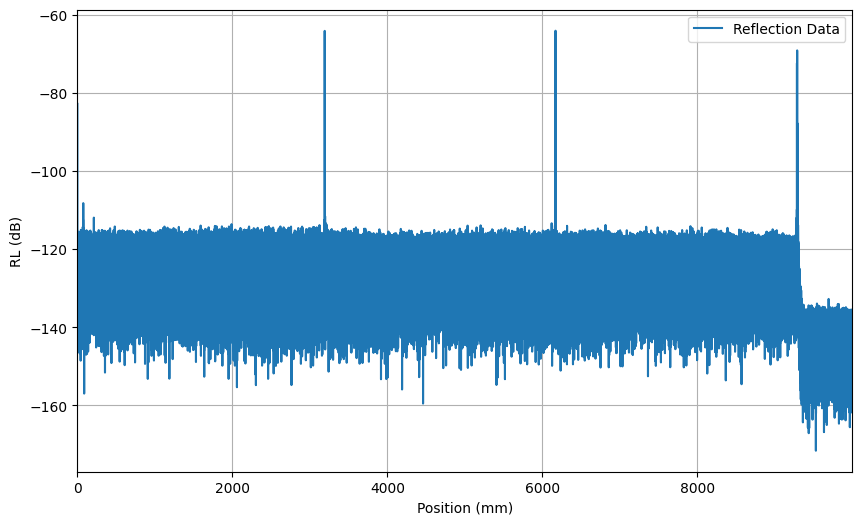

In [12]:
# Note: reconnect the DUT for measurement
# perform a measurement scan using the current settings
# using Scan() requires calling GetReflectanceMeasurement() afterwards
# This splits the physical scan and the data processing
# which allows for advanced processing techniques
# e.g. pipelining and processing a second scan and the previous data processing in parallel

startTime = time.perf_counter()

spa.SetOperationSettingsValue("MeasurementMode", 0)
spa.SetOperationSettingsValue("DistanceRange", 30)

# specify the range for the returned data
startPosition = 0
endPosition = 10000

# specify the Distance Correction Position
# positions get less accurate the further away from the Distance Correction Position
# if not specified, it will use the middle of the range above
distanceCorrectionPosition = 6000

status = spa.Scan()
status, xValues, yValues = spa.GetReflectanceData(startPosition, endPosition, distanceCorrectionPosition)

endTime = time.perf_counter()

print(f"Measurement took {endTime - startTime:.2f} seconds")

fig = plt.figure(figsize=(10, 6))
plt.plot(xValues, yValues, label='Reflection Data')
plt.xlabel('Position (mm)')
plt.ylabel('RL (dB)')
plt.legend()
plt.grid(True)
plt.xlim(min(xValues), max(xValues))
plt.show()

# clean up to free up memory
del xValues, yValues
plt.close(fig)

## Changing Processing Parameters and Apply to the Acquired Data

GaussianFilter = True
GaussianRadius = 0.1
Update took 1.03 seconds


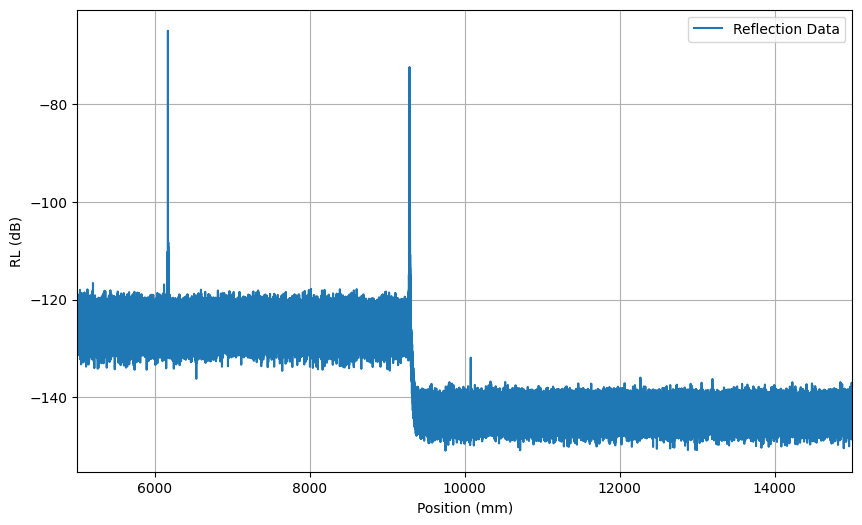

In [ ]:
# after a Scan or any of the Execute... functions that perform a scan
# use the spa.GetRawMeasurementData(startPosition, endPosition, distanceCorrectionPosition, [], [], reference)
# to get the data from the same scan at different ranges 
# or with different processing options applied (e.g. gaussian filter, dispersion compensation, distance correction position, etc.)

startTime = time.perf_counter()

# change Gaussian Filter settings
spa.SetOperationSettingsValue("GaussianFilter", Boolean(True))
spa.SetOperationSettingsValue("GaussianRadius", 0.1)

print("GaussianFilter =", spa.Settings.GaussianFilter)
print("GaussianRadius =", spa.Settings.GaussianRadius)

# change the range for the returned data
startPosition = 5000
endPosition = 15000

# specify the Distance Correction Position
# positions get less accurate the further away from the Distance Correction Position
# if not specified, and this is the first time the data is processed from a new scan
# either from a previous spa.GetReflectanceData or a spa.Execute... 
# it will use the midpoint of the range provided
# otherwise, it will not recalculate the correction until a value is explicitly specified

# this will not recalculate
status, xValues, yValues = spa.GetReflectanceData(startPosition, endPosition, None)

# this will recalculate using the specified distanceCorrectionPosition
# distanceCorrectionPosition = (startPosition + endPosition) / 2
# status, xValues, yValues = spa.GetReflectanceData(startPosition, endPosition, distanceCorrectionPosition)


endTime = time.perf_counter()

print(f"Update took {endTime - startTime:.2f} seconds")

fig = plt.figure(figsize=(10, 6))
plt.plot(xValues, yValues, label='Reflection Data')
plt.xlabel('Position (mm)')
plt.ylabel('RL (dB)')
plt.legend()
plt.grid(True)
plt.xlim(min(xValues), max(xValues))
plt.show()

# clean up to free up memory
del xValues, yValues
plt.close(fig)

## Peak Search

PeakThreshold = -80.0
PeakWidth = 1.0
peakPositionList = [3190.81568167049, 6169.36514517757, 9284.506433966417, 9287.431242773602]
peakValuesList = [-65.9636407009044, -64.96432222829237, -72.68611137411055, -72.445764144532]


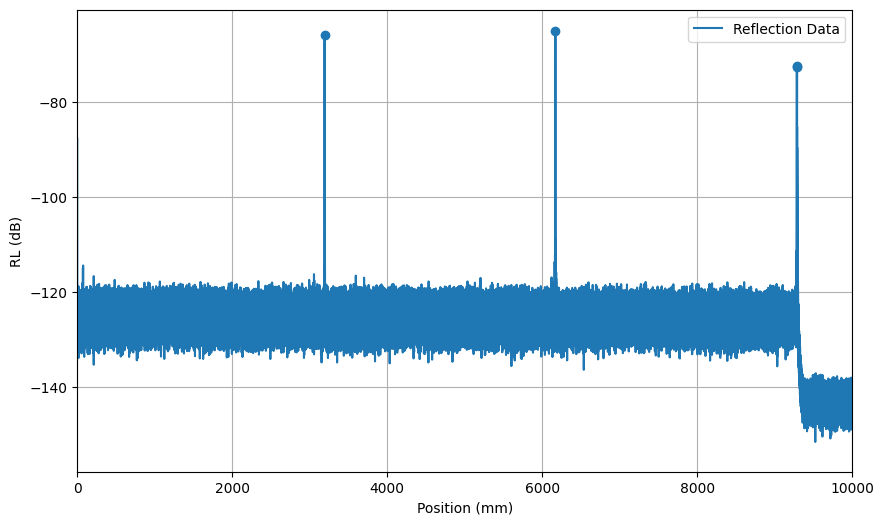

In [12]:
# set peak search parameters
spa.SetOperationSettingsValue("PeakThreshold", -80)
spa.SetOperationSettingsValue("PeakWidth", 1.0)
print("PeakThreshold =", spa.Settings.PeakThreshold)
print("PeakWidth =", spa.Settings.PeakWidth)


# scan from 0 to 6000 m, forward direction (0), first 10 peaks
# This combines the ExecuteReflectionMeasurement and GetPeaks function
status, peakPositionList, peakValuesList = spa.ExecutePeakScan(0, 10000, 0, 10, [], [])

print("peakPositionList =", list(peakPositionList))
print("peakValuesList =", list(peakValuesList))

status, xValues, yValues = spa.GetReflectanceData([], [])


fig = plt.figure(figsize=(10, 6))
plt.scatter(peakPositionList, peakValuesList)
plt.plot(xValues, yValues, label='Reflection Data')
plt.xlabel('Position (mm)')
plt.ylabel('RL (dB)')
plt.legend()
plt.grid(True)
plt.xlim(0, 10000)
plt.show()

# clean up to free up memory
del xValues, yValues
plt.close(fig)

## RL and IL Measurement

ILRange = 0.5
Peak Position: 3190.81568167049
RL = -56.57645908707308
IL = 0.005159815118635105


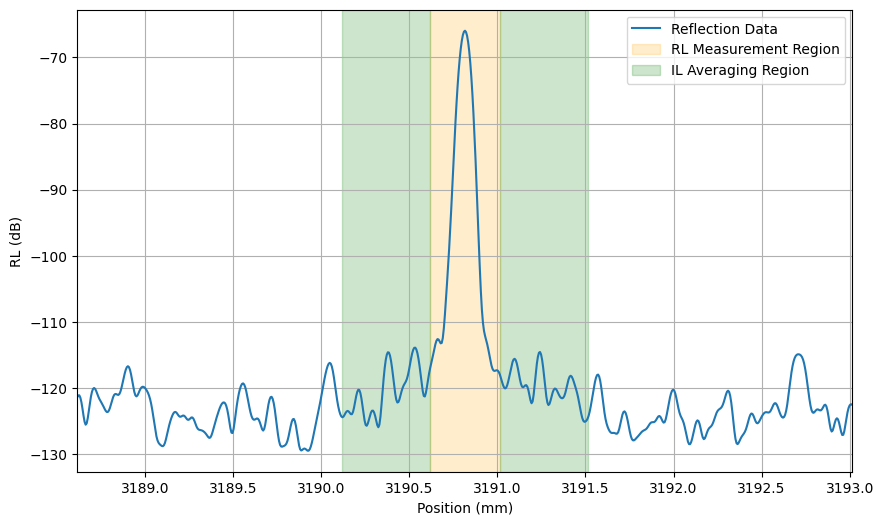

In [17]:
# Measure RL and IL around first peak found above

# use first peak position from the previous
# measure RL at rlRange mm radius around the peak
rlRange = 0.2
min = peakPositionList[0] - rlRange
max = peakPositionList[0] + rlRange

spa.Settings.IlRange = 0.5
ilRange = spa.Settings.IlRange
print("ILRange =", ilRange)

status, rlValue = spa.MeasureRL(min, max)
status, ilValue = spa.MeasureIL(min, max)

print(f"Peak Position: {peakPositionList[0]}")
print("RL =", rlValue)
print("IL =", ilValue)

status, xValues, yValues = spa.GetReflectanceData(min - 2, max + 2, None)

plt.figure(figsize=(10, 6))
plt.plot(xValues, yValues, label='Reflection Data')
plt.axvspan(min, max, color='orange', alpha=0.2, label='RL Measurement Region')
plt.axvspan(min - ilRange, min, color='green', alpha=0.2, label='IL Averaging Region')
plt.axvspan(max, max + ilRange, color='green', alpha=0.2)
plt.xlabel('Position (mm)')
plt.ylabel('RL (dB)')
plt.legend()
plt.grid(True)
plt.xlim(min - 2, max + 2)
plt.show()

# clean up to free up memory
del xValues, yValues
plt.close(fig)

## Save DSPA

In [11]:
# save the scan data and settings to a SPA Data File (DSPA)
filepath = "./data/SPA-200_Test.dspa"
spa.SaveDSPAFile(filepath)

0

# Analysis Mode (no connected instruments)

## Load DSPA
### (Make sure to run Cell 1 "SPA Module Creation" first)

In [4]:
# Make sure to run Cell 1 "SPA Module Creation" first

filepath = "./data/SPA-200_Test.dspa"

if os.path.isfile(filepath):
    status = spa.LoadDSPAFile(filepath)
    print(status)
else:
    print("DSPA file not found")


0


# Get Reflectance Data from Loaded DSP

Measurement took 3.90 seconds


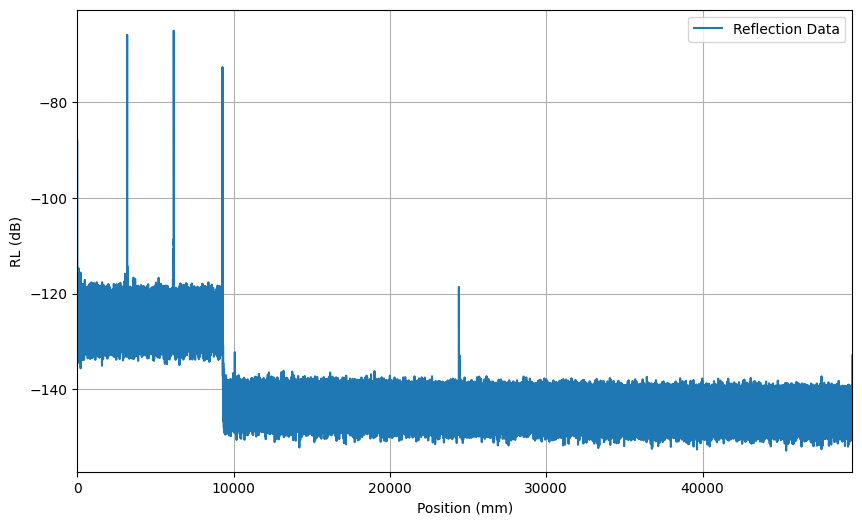

In [5]:
startTime = time.perf_counter()

# Calculate the reference offsets
status, reflectionReference = spa.GetReflectanceReferenceOffset()

# specify the range for the returned data
# set both to 0 to get the entire range
startPosition = 0
endPosition = 0

# specify the Distance Correction Position
# positions get less accurate the further away from the Distance Correction Position
# if not specified, it will use the middle of the range above
distanceCorrectionPosition = 6000

status, xValues, yValues = spa.GetReflectanceData(startPosition, endPosition, distanceCorrectionPosition)

endTime = time.perf_counter()

print(f"Measurement took {endTime - startTime:.2f} seconds")

fig = plt.figure(figsize=(10, 6))
plt.plot(xValues, yValues, label='Reflection Data')
plt.xlabel('Position (mm)')
plt.ylabel('RL (dB)')
plt.legend()
plt.grid(True)
plt.xlim(min(xValues), max(xValues))
plt.show()

# clean up to free up memory
del xValues, yValues
plt.close(fig)